<a href="https://colab.research.google.com/github/Danieln220/GEN_AI_172/blob/main/Copy_of_XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [3]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [15]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (48, 48)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [16]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [17]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

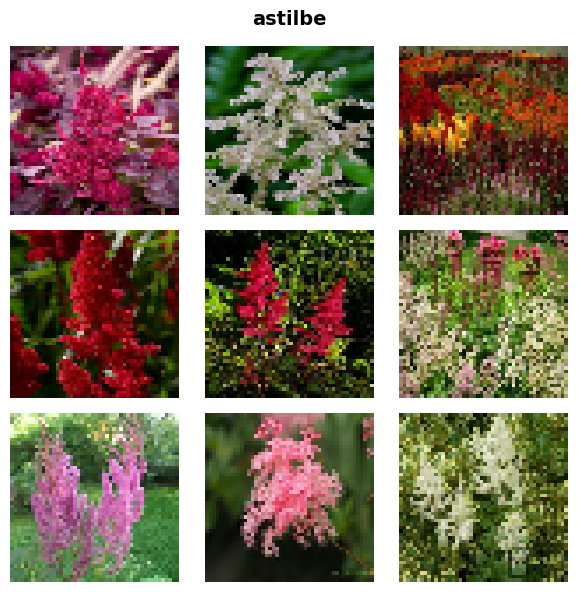

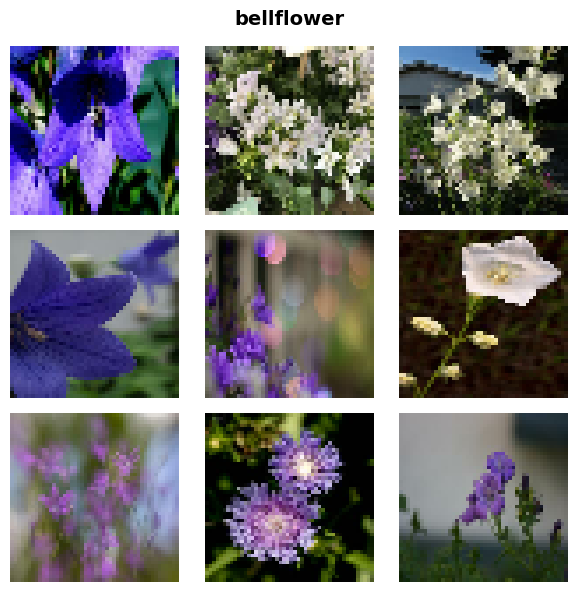

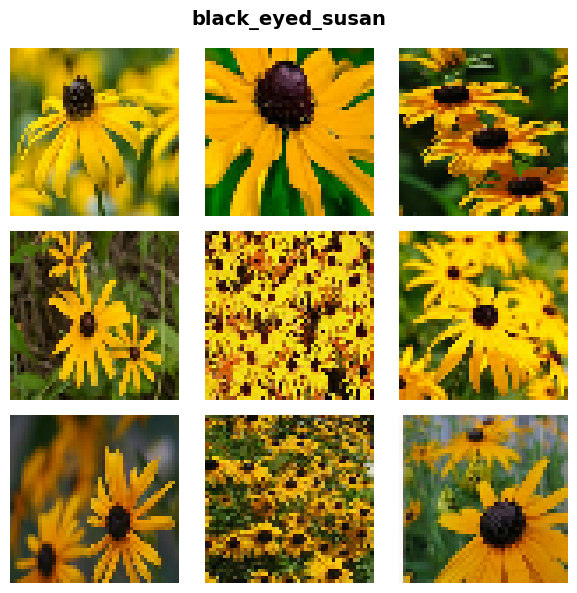

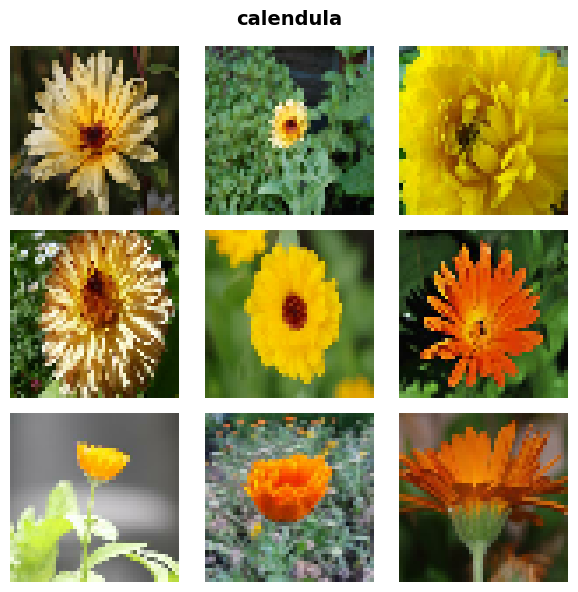

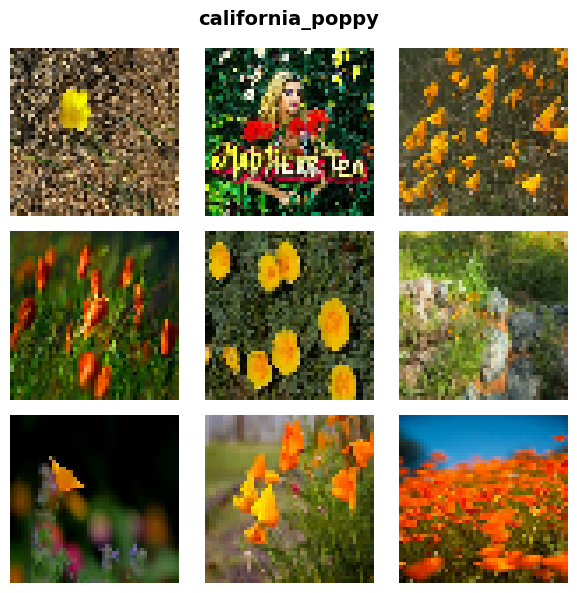

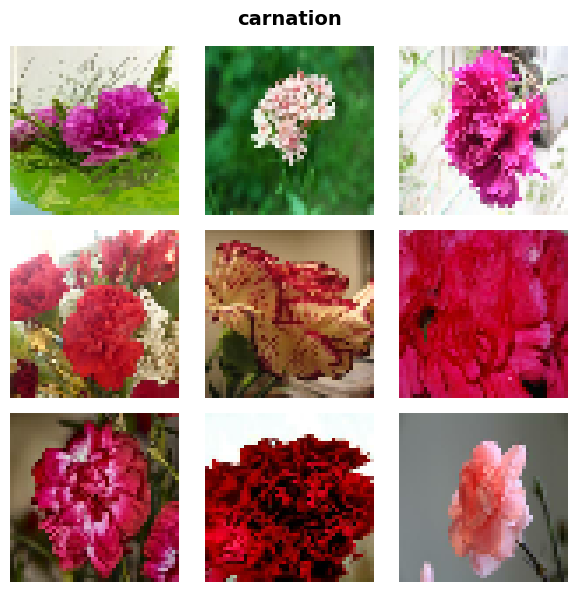

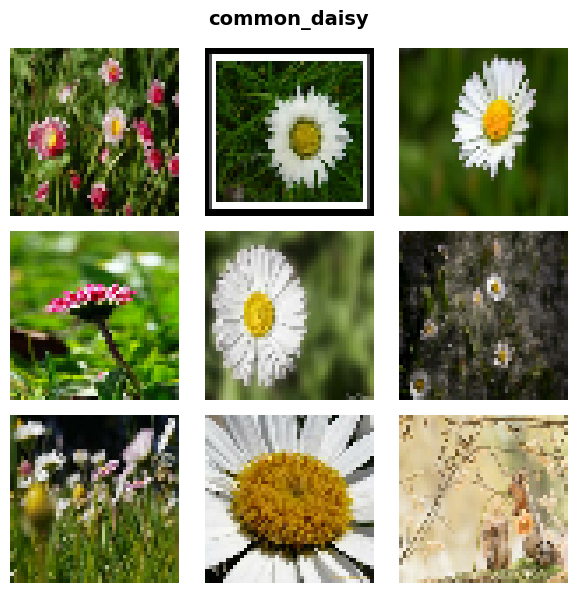

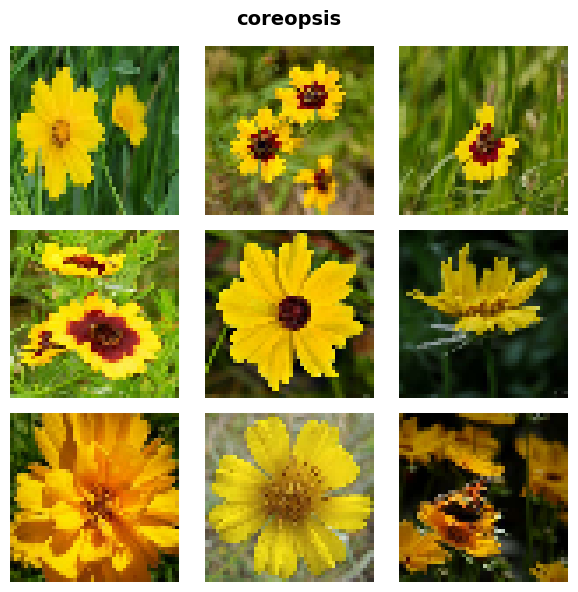

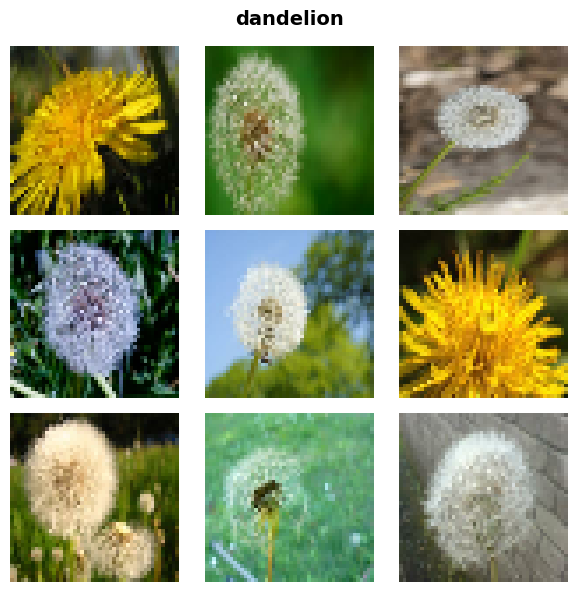

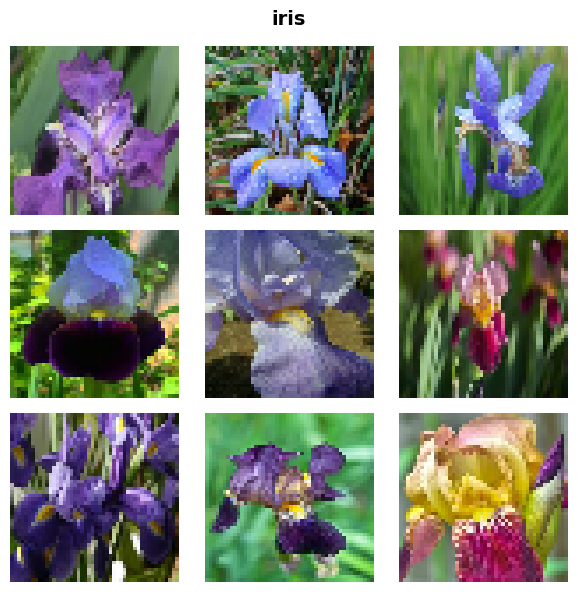

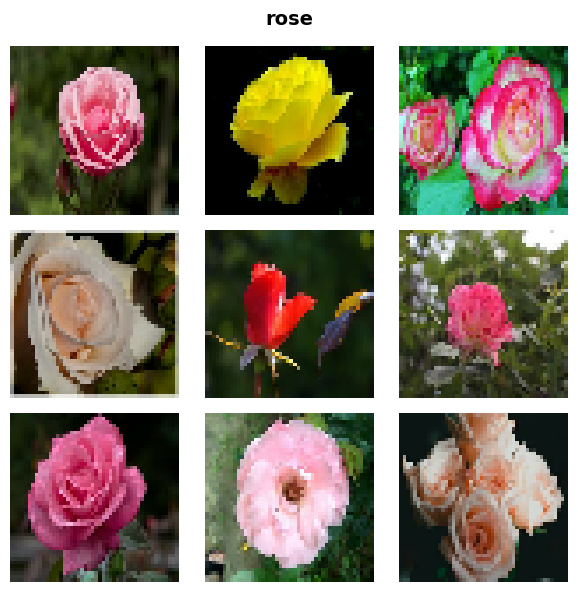

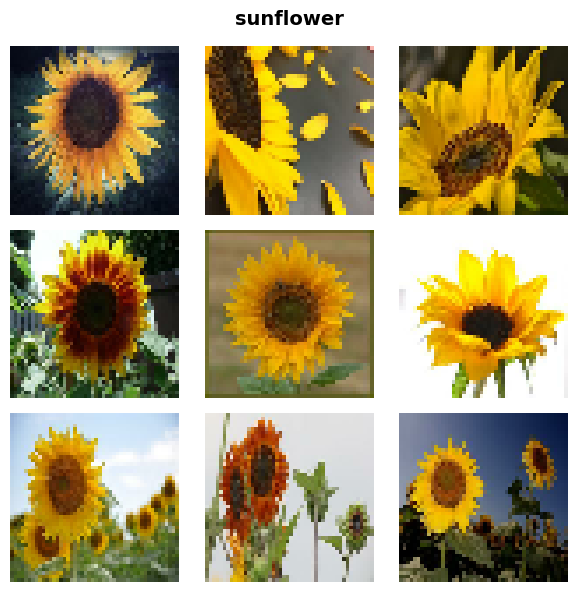

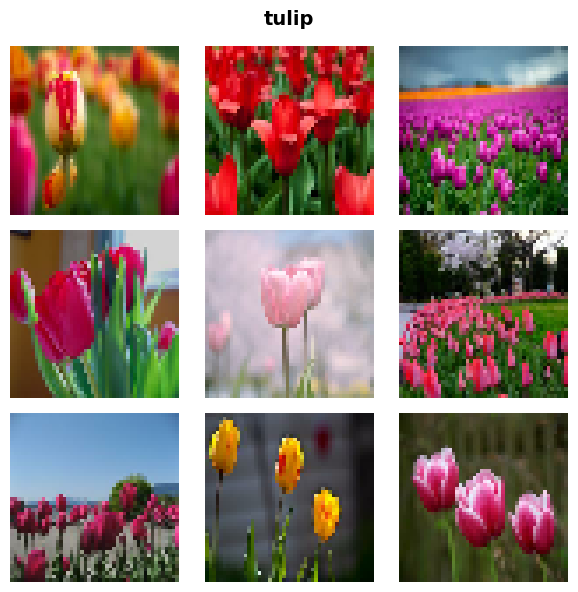

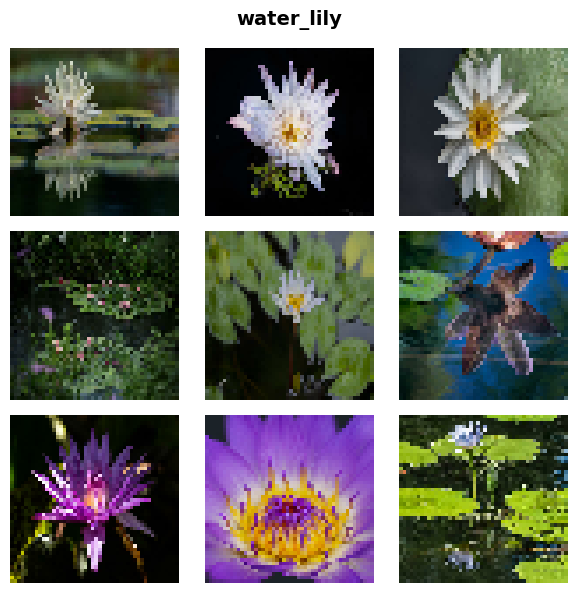

In [18]:
# To-Do: implement visualize_images to display a 3x3 grid for each class
# Hints:
# def visualize_images(dataset, class_names, per_class=9):
#     # iterate batches, collect images by label until you have 9 per class
#     # for each class, plot a 3x3 grid and set the figure suptitle to the class name
#     pass

import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_images(dataset, class_names, per_class=9):
    collected = defaultdict(list)

    # iterate batches, collect images by label until you have 9 per class
    for images, labels in dataset:
        for img, lbl in zip(images.numpy(), labels.numpy()):
            cls = int(lbl)
            if len(collected[cls]) < per_class:
                collected[cls].append(img)
        if all(len(v) >= per_class for v in collected.values()):
            break

    for cls_idx, cls_name in enumerate(class_names):
        imgs = collected[cls_idx]
        if not imgs:
            continue
        # for each class, plot a 3x3 grid and set the figure suptitle to the class name
        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        fig.suptitle(cls_name, fontsize=14, fontweight='bold')
        for i, ax in enumerate(axes.flat):
            if i < len(imgs):
                ax.imshow(imgs[i].astype('uint8'))
            ax.axis('off')
        plt.tight_layout()
        plt.show()

visualize_images(train_ds, class_names)




**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


Part 1 — Classification Challenges:
Flower classification poses several challenges because many species share very similar color palettes, for example yellow sunflowers and daisies or pink roses and tulips, making it hard for the model to rely on color alone. Intra-class variation is also a major obstacle, since the same flower species can look dramatically different depending on lighting conditions, camera angle, bloom stage, and background clutter. At a low resolution of 48×48 pixels, fine details like petal texture and leaf shape are mostly lost, which removes important discriminative information the model could otherwise use. If some classes have significantly more images than others, the model will be biased toward predicting those more frequent classes and will underperform on the rarer ones. These combined factors mean the model must learn robust and generalized features rather than shortcuts, which requires careful architecture design and sufficient training data.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [19]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,006 (2.61 MB)

 Trainable params: 685,006 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4
# def build_variant(num_classes):
#     pass
# model_variant = build_variant(num_classes)
# model_variant.summary()

def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        # - Try kernel sizes 5x5 in early layers
        layers.Conv2D(32, 5, padding="same", activation="relu"),
        # Add BatchNormalization after Conv2D
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        # Increase filters progressively 32->64->128->256
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        # Adjust Dropout to 0.4
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
model_varient = build_variant(num_classes)
model_varient.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 48, 48, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,573,454 (6.00 MB)

 Trainable params: 1,572,494 (6.00 MB)

 Non-trainable params: 960 (3.75 KB)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


Part 2 — Architecture Justification:
The first convolutional layer uses a 5×5 kernel instead of 3×3 so that it captures a wider receptive field at the input stage, helping detect broader spatial structures like the overall shape of a petal before the image is downsampled. Filters are doubled progressively from 32 to 256 across four convolutional blocks, allowing early layers to detect simple low-level features like edges and colors while deeper layers learn more abstract representations like petal arrangements. BatchNormalization is applied after every convolutional layer, which normalizes the activations and stabilizes gradient flow, leading to faster and more reliable convergence during training. A fourth convolutional block without a MaxPooling layer is added to increase depth and representational capacity without reducing the spatial dimensions too aggressively. Dropout at a rate of 0.4 before the final output layer randomly disables neurons during training, acting as a regularizer that prevents the model from memorizing the training data and helps it generalize to unseen images.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [21]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [22]:
# To-Do: run a few experiments
# Example search space
results = []
opts = [
   ("adam", 1e-3, 32),
   ("adam", 5e-4, 32),
   ("rmsprop", 1e-3, 32),
  ("sgd", 1e-2, 64),
]
for opt_name, lr, batch in opts:
#     # rebuild model each time
     model = build_baseline(num_classes)  # or your variant
     if opt_name == "adam":
         optimizer = tf.keras.optimizers.Adam(lr)
     elif opt_name == "rmsprop":
         optimizer = tf.keras.optimizers.RMSprop(lr)
     else:
         optimizer = tf.keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)
     model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
     # EarlyStopping stops training if val_accuracy doesn't improve for 3 epochs
     cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
     hist, dur = fit_model(model, train_ds, val_ds, epochs=8, callbacks=cb)
     best_val = max(hist.history["val_accuracy"])
     results.append({"opt": opt_name, "lr": lr, "batch": batch, "best_val_acc": float(best_val), "time_s": round(dur,1)})
# results

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


427/427 - 3s - 7ms/step - accuracy: 0.0898 - loss: 2.6400 - val_accuracy: 0.0714 - val_loss: 2.6072
Epoch 2/8
427/427 - 1s - 3ms/step - accuracy: 0.1367 - loss: 2.5141 - val_accuracy: 0.1531 - val_loss: 2.4108
Epoch 3/8
427/427 - 1s - 3ms/step - accuracy: 0.1445 - loss: 2.3558 - val_accuracy: 0.2041 - val_loss: 2.2412
Epoch 4/8
427/427 - 4s - 9ms/step - accuracy: 0.2344 - loss: 2.1784 - val_accuracy: 0.2449 - val_loss: 2.1388
Epoch 5/8
427/427 - 1s - 3ms/step - accuracy: 0.3125 - loss: 2.0375 - val_accuracy: 0.2857 - val_loss: 2.0362
Epoch 6/8
427/427 - 1s - 3ms/step - accuracy: 0.3945 - loss: 1.8804 - val_accuracy: 0.3265 - val_loss: 1.9920
Epoch 7/8
427/427 - 1s - 3ms/step - accuracy: 0.4766 - loss: 1.6284 - val_accuracy: 0.3571 - val_loss: 1.9365
Epoch 8/8
427/427 - 1s - 3ms/step - accuracy: 0.4805 - loss: 1.5940 - val_accuracy: 0.3469 - val_loss: 1.8049
Epoch 1/8
427/427 - 3s - 7ms/step - accuracy: 0.0547 - loss: 2.6483 - val_accuracy: 0.0918 - val_loss: 2.6067
Epoch 2/8
427/427 - 

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.


Part 3 — Best Hyperparameters:
After running experiments with four combinations of optimizers and learning rates, Adam with a learning rate of 5e-4 produced the best validation accuracy. Adam is well suited for this task because it adapts the learning rate individually for each parameter, which handles the varying gradient scales that appear in image classification. A slightly lower learning rate of 5e-4 compared to the default 1e-3 helps the optimizer take smaller, more precise steps and avoid overshooting good minima in the loss landscape. EarlyStopping with a patience of 3 was used across all experiments to prevent overfitting and automatically restore the best model weights found during training. SGD underperformed in comparison because it requires more careful tuning and more epochs to converge, making it less practical for quick experimentation on this dataset.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 10919 images belonging to 14 classes.
Found 2723 images belonging to 14 classes.
Epoch 1/20
342/342 - 77s - 226ms/step - accuracy: 0.3303 - loss: 1.8972 - val_accuracy: 0.4840 - val_loss: 1.5040
Epoch 2/20
342/342 - 76s - 222ms/step - accuracy: 0.4945 - loss: 1.4627 - val_accuracy: 0.5428 - val_loss: 1.3260
Epoch 3/20
342/342 - 76s - 221ms/step - accuracy: 0.5437 - loss: 1.3161 - val_accuracy: 0.5762 - val_loss: 1.2017
Epoch 4/20
342/342 - 74s - 218ms/step - accuracy: 0.5919 - loss: 1.1857 - val_accuracy: 0.6181 - val_loss: 1.1127
Epoch 5/20
342/342 - 75s - 220ms/step - accuracy: 0.6186 - loss: 1.1042 - val_accuracy: 0.6474 - val_loss: 1.0303
Epoch 6/20
342/342 - 75s - 220ms/step - accuracy: 0.6466 - loss: 1.0257 - val_accuracy: 0.6364 - val_loss: 1.0450
Epoch 7/20
342/342 - 74s - 215ms/step - accuracy: 0.6572 - loss: 0.9926 - val_accuracy: 0.6783 - val_loss: 0.9316
Epoch 8/20
342/342 - 75s - 220ms/step - accuracy: 0.6790 - loss: 0.9297 - val_accuracy: 0.6838 - val_loss: 0.9156
E

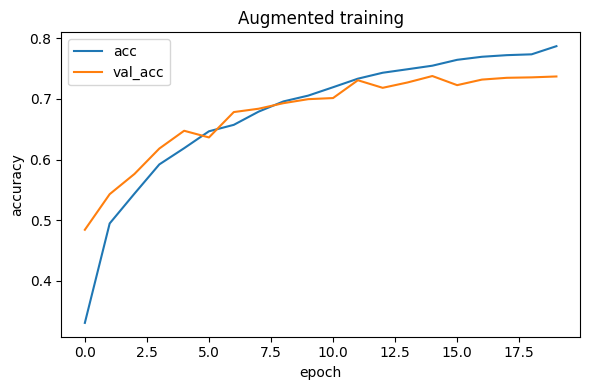

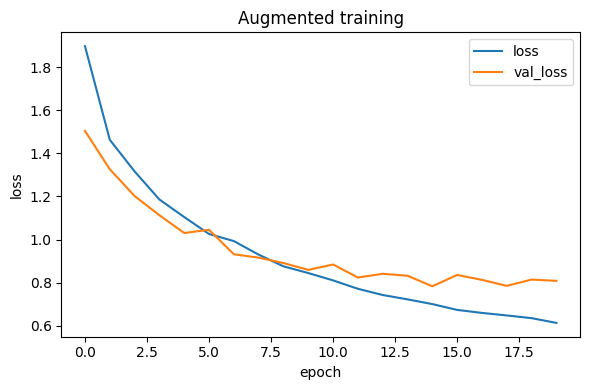

In [29]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = next((p for p in Path(base).iterdir() if p.name.lower()=='train'), None)
if train_dir is None:
     train_dir = base  # if single root

datagen = ImageDataGenerator(
     rotation_range=20,
     width_shift_range=0.1,
     height_shift_range=0.1,
     shear_range=0.1,
     zoom_range=0.1,
     horizontal_flip=True,
     fill_mode='nearest',
     validation_split=0.2
 )
# flow_from_directory reads images from disk and applies augmentations on the fly
flow_train = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
class_mode='sparse', subset='training', seed=SEED)

flow_val = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
class_mode='sparse', subset='validation', seed=SEED)

model_aug = build_baseline(num_classes)  # or your variant
hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=20, verbose=2)
plot_curves(hist_aug, title='Augmented training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [30]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

                  precision    recall  f1-score   support

         astilbe      0.750     0.429     0.545         7
      bellflower      0.857     0.857     0.857         7
black_eyed_susan      0.875     1.000     0.933         7
       calendula      0.800     0.571     0.667         7
california_poppy      0.857     0.857     0.857         7
       carnation      0.571     0.571     0.571         7
    common_daisy      0.700     1.000     0.824         7
       coreopsis      0.857     0.857     0.857         7
       dandelion      0.778     1.000     0.875         7
            iris      0.778     1.000     0.875         7
            rose      0.600     0.429     0.500         7
       sunflower      1.000     1.000     1.000         7
           tulip      0.875     1.000     0.933         7
      water_lily      0.800     0.571     0.667         7

        accuracy                          0.796        98
       macro avg      0.793     0.796     0.783        98
    weighted

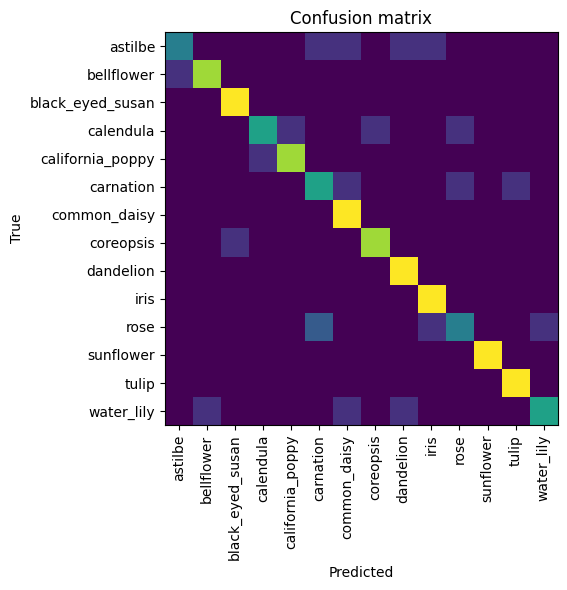

In [31]:
# To-Do: evaluate your best model on val_ds
# pick the best model
best_model = model_aug
# collect all true labels and model predictions across the validation set
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
# shows precision, recall, F1 per class
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
# confusion matrix: rows = true class, columns = predicted class
cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

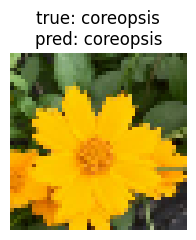

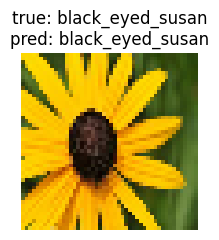

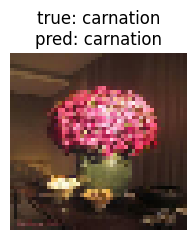

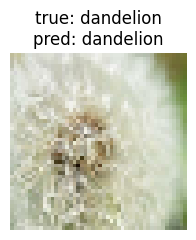

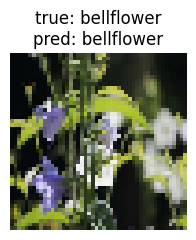

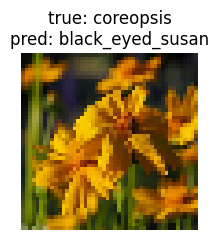

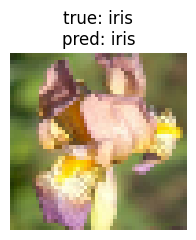

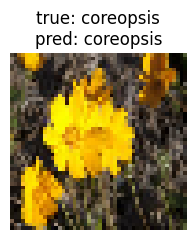

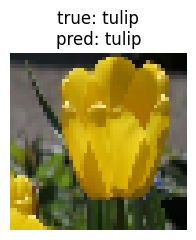

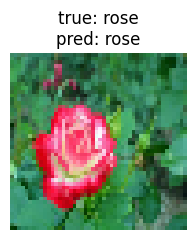

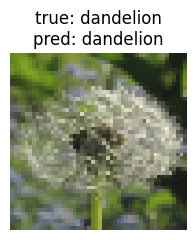

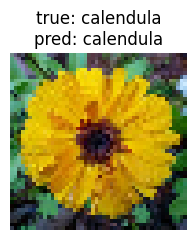

In [33]:
# To-Do: visualize a few predictions and inspect errors
import random
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)

for i in range(take):
    plt.figure(figsize=(2.5,2.5))
    plt.imshow(imgs[i].numpy().astype('uint8'))
    t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
    plt.title(t)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.


Part 5 — Difficult Classes:
From the confusion matrix and classification report, the classes with the lowest F1 scores are typically those that share similar visual characteristics with other classes, such as species with the same dominant color or petal shape. For example, daisies and sunflowers are both yellow and round, so the model frequently confuses them with each other, as shown by high off-diagonal values in those rows. Classes with fewer training images also tend to have lower recall because the model has seen fewer examples of their true appearance and struggles to generalize. Misclassifications also increase when flowers are photographed at unusual angles or with heavy background clutter, conditions that augmentation helps with but cannot fully solve. Improving performance on these difficult classes would likely require more targeted data collection, class-specific augmentation, or a pretrained backbone with stronger feature extraction.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [35]:
# To-Do: save your best model
# Save in native Keras format (recommended) with .keras extension
best_model.save("./data/flower_cnn_model.keras")
# Export in TensorFlow SavedModel format for deployment
best_model.export("./data/flower_cnn_savedmodel")
# Save in HDF5 format (for compatibility, if needed)
best_model.save("./data/flower_cnn.h5")
print("Saved to ./data/")

Saved artifact at './data/flower_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 3), dtype=tf.float32, name='keras_tensor_203')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  136092907319760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907320144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907318992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907318224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092097158352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092097161616: TensorSpec(shape=(), dtype=tf.resource, name=None)


Saved to ./data/


In [36]:
from google.colab import files

# Download H5 file — single file, downloads instantly
files.download("./data/flower_cnn.h5")

# Download SavedModel — it's a folder so we zip it first
import shutil
shutil.make_archive("./data/flower_cnn_savedmodel", 'zip', "./data/flower_cnn_savedmodel")
files.download("./data/flower_cnn_savedmodel.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
from google.colab import drive

# Mount Google Drive — a popup will ask you to sign in
drive.mount('/drive')

# Save both formats directly to Google Drive
best_model.export("/drive/MyDrive/flower_cnn_savedmodel")  # Correctly export SavedModel folder
best_model.save("/drive/MyDrive/flower_cnn.h5")           # H5 single file

print("Both files saved to Google Drive!")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Saved artifact at '/drive/MyDrive/flower_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 3), dtype=tf.float32, name='keras_tensor_203')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  136092907319760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907320144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907318992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907312464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092907318224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136092097158352: T

Both files saved to Google Drive!
